In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import kwant

import sqoct_core as sq


FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

In [2]:
t1 = 1.0
t2 = 0.50
Delta = 0.20

Nx = 10
Ny = 6

mu_values = np.arange(-1.30, 1.201, 0.025)

eta_sc = 1e-8
eta_dos = 0.035

In [3]:
def build_system():

    syst = kwant.Builder()

    T1 = sq.hopping_bdg(t1)
    T2 = sq.hopping_bdg(t2)

    # Sites
    for ix in range(Nx):
        for iy in range(Ny):

            syst[sq.A(ix, iy)] = sq.onsite_clean
            syst[sq.B(ix, iy)] = sq.onsite_clean
            syst[sq.C(ix, iy)] = sq.onsite_clean
            syst[sq.D(ix, iy)] = sq.onsite_clean

    # Impurity location
    impurity = sq.A(Nx // 2, Ny // 2)
    syst[impurity] = sq.onsite_impurity

    # Hoppings
    for ix in range(Nx):
        for iy in range(Ny):

            # Square edges
            syst[sq.A(ix, iy), sq.B(ix, iy)] = T1
            syst[sq.B(ix, iy), sq.C(ix, iy)] = T1
            syst[sq.C(ix, iy), sq.D(ix, iy)] = T1
            syst[sq.D(ix, iy), sq.A(ix, iy)] = T1

            # Diagonal hoppings
            syst[sq.A(ix, iy), sq.C(ix, iy)] = T2
            syst[sq.B(ix, iy), sq.D(ix, iy)] = T2

            # Periodic boundary conditions
            syst[sq.C(ix, iy), sq.A(ix, (iy + 1) % Ny)] = T1
            syst[sq.B(ix, iy), sq.D((ix + 1) % Nx, iy)] = T1

    fsyst = syst.finalized()
    impurity_index = fsyst.id_by_site[impurity]

    return fsyst, impurity_index

In [4]:
fsyst, imp_idx = build_system()


g_values = []
f_values = []
lambda_values = []


for mu in mu_values:

    Gii = sq.local_clean_green(
        fsyst, imp_idx,
        mu=mu, Delta=Delta,
        E=0.0, eta=eta_sc
    )

    # Reduced spin-Nambu sector: (c_up, c_down^dagger)
    G = Gii[np.ix_([0, 3], [0, 3])]

    # Remove the tiny numerical anti-Hermitian part
    G = 0.5 * (G + G.conj().T)

    ge = G[0, 0].real
    gh = G[1, 1].real
    f = G[0, 1]

    gbar = 0.5 * (ge + gh)
    dg = 0.5 * (ge - gh)

    lambda_plus = gbar + np.sqrt(dg**2 + np.abs(f)**2)

    g_values.append(np.abs(ge))
    f_values.append(np.abs(f))
    lambda_values.append(lambda_plus)


g_values = np.array(g_values)
f_values = np.array(f_values)
lambda_values = np.array(lambda_values)

In [5]:
rho = sq.normal_local_dos(
    fsyst, imp_idx,
    energies=mu_values,
    eta=eta_dos
)

In [6]:
rho_norm = rho / np.max(rho)
lambda_norm = lambda_values / np.max(lambda_values)

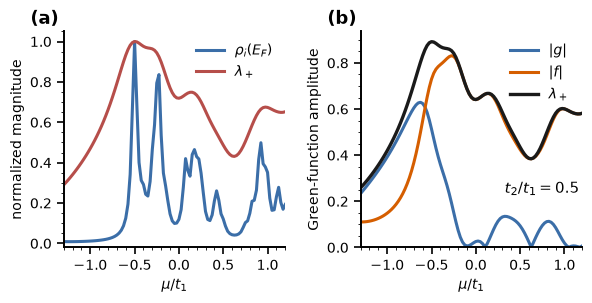

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(6.1, 3.0))

ax1, ax2 = axes


# Normal-state LDOS and YSR kernel

ax1.plot(
    mu_values, rho_norm,
    color="#3B6EA8", lw=2.2,
    label=r"$\rho_i(E_F)$"
)

ax1.plot(
    mu_values, lambda_norm,
    color="#B64E4A", lw=2.2,
    label=r"$\lambda_+$"
)

ax1.set_xlabel(r"$\mu/t_1$")
ax1.set_ylabel("normalized magnitude")

ax1.set_xlim(mu_values[0], mu_values[-1])
ax1.set_ylim(-0.02, 1.05)

ax1.legend(loc="upper right", frameon=False)


# Normal and anomalous Green-function contributions

ax2.plot(
    mu_values, g_values,
    color="#3B6EA8", lw=2.2,
    label=r"$|g|$"
)

ax2.plot(
    mu_values, f_values,
    color="#D55E00", lw=2.2,
    label=r"$|f|$"
)

ax2.plot(
    mu_values, lambda_values,
    color="0.10", lw=2.4,
    label=r"$\lambda_+$"
)

ax2.set_xlabel(r"$\mu/t_1$")
ax2.set_ylabel("Green-function amplitude")

ax2.set_xlim(mu_values[0], mu_values[-1])
ax2.set_ylim(bottom=0)

ax2.text(
    0.65, 0.25,
    rf"$t_2/t_1={t2:g}$",
    transform=ax2.transAxes,
    fontsize=11
)

ax2.legend(loc="upper right", frameon=False)

for ax in axes:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(1.4)
    ax.spines["bottom"].set_linewidth(1.4)

    ax.tick_params(
        direction="out",
        length=5, width=1.2,
        top=False, right=False
    )

    ax.minorticks_on()


# Panel labels
ax1.text(
    -0.15, 1.035, "(a)",
    transform=ax1.transAxes,
    fontsize=13, fontweight="bold"
)

ax2.text(
    -0.15, 1.035, "(b)",
    transform=ax2.transAxes,
    fontsize=13, fontweight="bold"
)


fig.subplots_adjust(
    left=0.135, right=0.985,
    bottom=0.20, top=0.92,
    wspace=0.34
)

# fig.savefig(
#     FIG_DIR / "green_single_impurity.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()